# 📈 Zero-Shot Zaman Serisi Tahmini: Chronos vs TimesFM 2.5
## S&P 500 üzerinde Amazon ve Google Foundation Modellerinin Karşılaştırması

---

### Bu Notebook'ta Ne Öğreneceğiz?

**Zero-shot (sıfır-atış) tahmin nedir?**
Geleneksel ML'de modeli eğitmek için veri gerekir.
Zero-shot'ta ise model daha önce hiç görmediği bir zaman serisini
**doğrudan tahmin edebilir** — tıpkı GPT'nin hiç görmediği bir soruyu cevaplaması gibi.

**Modellerimiz:**
| Model | Geliştiren | Parametre | Mimari | Özellik |
|-------|-----------|-----------|--------|---------|
| Chronos-T5-Small | Amazon | ~46M | T5 encoder-decoder | Probabilistik sampling |
| TimesFM-2.5-200M | Google | ~200M | Patched decoder-only | GIFT-Eval zero-shot #1 |

**Değerlendirme:**
Her modeli aynı S&P 500 verisiyle test edip MAE, RMSE, MAPE metriklerini karşılaştıracağız.
Naive ve Moving Average baseline'larla da kıyaslayacağız.


🚨 Bu not defteri, Chronos ve TimesFM gibi temel modelleri kullanarak zaman serisi tahminleri yapmak için, dayanıklı ve hatalara karşı toleranslı bir deney hattı olarak tasarlanmıştır.

Günümüzde makine öğrenimi iş akışları—özellikle büyük önceden eğitilmiş modellere dayanan sistemler—paket ve bağımlılık uyumsuzlukları, hızla değişen API’ler (örneğin TimesFM sürümleri), HuggingFace gibi platformlardan model yüklerken yaşanan sorunlar, donanım kısıtları (CPU/GPU farkları) ve model indirme sırasında ortaya çıkabilen ağ problemleri gibi birçok etkene karşı hassas olabilir.

Bu nedenle bu not defteri, kusursuz ve tamamen stabil bir ortam varsaymak yerine, bu tür belirsizlikleri doğal kabul eder ve farklı hata senaryoları altında da çalışmaya devam edebilecek şekilde tasarlanmıştır.

## 🔧 1. Kurulum

İlk çalıştırmada bu hücreyi çalıştır, sonra kernel'ı yeniden başlat.

In [1]:
'''
# Chronos: Amazon'un zaman serisi foundation modeli
!pip install git+https://github.com/amazon-science/chronos-forecasting.git -q

# TimesFM 2.5: GitHub'dan kur (PyPI paketi eski versiyonları içeriyor)
!pip install git+https://github.com/google-research/timesfm.git -q

# Finansal veri + diğer bağımlılıklar
!pip install yfinance pandas_datareader scikit-learn matplotlib -q

# HuggingFace Hub güncelle
!pip install -U huggingface_hub

# Transformers güncelle
!pip install -U transformers

print("✅ Kurulum tamamlandı — kernel'ı yeniden başlat (Runtime → Restart).")
'''

'\n# Chronos: Amazon\'un zaman serisi foundation modeli\n!pip install git+https://github.com/amazon-science/chronos-forecasting.git -q\n\n# TimesFM 2.5: GitHub\'dan kur (PyPI paketi eski versiyonları içeriyor)\n!pip install git+https://github.com/google-research/timesfm.git -q\n\n# Finansal veri + diğer bağımlılıklar\n!pip install yfinance pandas_datareader scikit-learn matplotlib -q\n\n# HuggingFace Hub güncelle\n!pip install -U huggingface_hub\n\n# Transformers güncelle\n!pip install -U transformers\n\nprint("✅ Kurulum tamamlandı — kernel\'ı yeniden başlat (Runtime → Restart).")\n'

In [2]:
import timesfm

print("OK:", 'TimesFM_2p5_200M_torch' in dir(timesfm))

OK: True


In [3]:
print(timesfm.TimesFM_2p5_200M_torch)

<class 'timesfm.timesfm_2p5.timesfm_2p5_torch.TimesFM_2p5_200M_torch'>


## 📦 2. Import ve Konfigürasyon

In [4]:
import warnings, os, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import importlib.metadata

import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
from chronos import ChronosPipeline
import timesfm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

print("✅ Importlar tamam")
print(f"PyTorch : {torch.__version__}")
# print(f"TimesFM : {importlib.metadata.version("timesfm")}")

✅ Importlar tamam
PyTorch : 2.11.0


## 📊 3. S&P 500 Verisi

**Strateji:**
- **Context:** Modele verilen geçmiş — son 365 iş günü
- **Horizon:** Tahmin edilecek gün sayısı — 30 gün
- **Test seti:** Son 30 günü gizli tutuyoruz; tahmin vs gerçek karşılaştırması için

Fallback zinciri: yfinance SPY → stooq ^SPX → sentetik GBM


In [5]:
CONTEXT_DAYS     = 365
FORECAST_HORIZON = 30
TOTAL_DAYS       = CONTEXT_DAYS + FORECAST_HORIZON + 60   # buffer

prices = None

# ── Yöntem 1: yfinance SPY ────────────────────────────────────────────────────
# SPY: S&P 500 ETF — ^GSPC'den daha güvenilir erişim, ×10 ile endeks seviyesine çekiyoruz
try:
    end_dt   = datetime.today()
    start_dt = end_dt - timedelta(days=900)
    raw = yf.download("SPY",
                      start=start_dt.strftime("%Y-%m-%d"),
                      end=end_dt.strftime("%Y-%m-%d"),
                      interval="1d", auto_adjust=True, progress=False)
    if len(raw) > 200:
        prices = (raw["Close"].dropna() * 10).squeeze()
        print(f"✅ Yöntem 1: yfinance SPY — {len(prices)} gün")
    else:
        print("⚠️ Yöntem 1 boş, Yöntem 2 deneniyor...")
except Exception as e:
    print(f"⚠️ Yöntem 1 başarısız ({type(e).__name__}), Yöntem 2 deneniyor...")

# ── Yöntem 2: stooq.com ───────────────────────────────────────────────────────
if prices is None or len(prices) < 200:
    try:
        import pandas_datareader.data as web
        end_dt   = datetime.today()
        start_dt = end_dt - timedelta(days=900)
        raw = web.DataReader("^SPX", "stooq", start_dt, end_dt).sort_index()
        if len(raw) > 200:
            prices = raw["Close"].dropna().squeeze()
            print(f"✅ Yöntem 2: stooq ^SPX — {len(prices)} gün")
        else:
            print("⚠️ Yöntem 2 boş, sentetik veriye geçiliyor...")
    except Exception as e:
        print(f"⚠️ Yöntem 2 başarısız ({type(e).__name__}), sentetik veriye geçiliyor...")

# ── Yöntem 3: Sentetik GBM ────────────────────────────────────────────────────
# S(t) = S(t-1) * exp((μ - σ²/2)dt + σ√dt * Z), Z ~ N(0,1)
if prices is None or len(prices) < 200:
    print("\n🔧 Sentetik GBM verisi üretiliyor...")
    np.random.seed(42)
    dt        = 1/252
    shocks    = (0.10 - 0.5*0.18**2)*dt + 0.18*np.sqrt(dt)*np.random.randn(TOTAL_DAYS)
    price_arr = 5000.0 * np.exp(np.cumsum(shocks))
    biz_days  = pd.bdate_range(end=datetime.today(), periods=TOTAL_DAYS)
    prices    = pd.Series(price_arr, index=biz_days, name="Close")
    print(f"✅ Sentetik veri — {len(prices)} gün  ⚠️ Gerçek değil, sadece test amaçlı")

# ── Context / Test Ayır ───────────────────────────────────────────────────────
prices = prices.squeeze()
if len(prices) > TOTAL_DAYS:
    prices = prices.iloc[-TOTAL_DAYS:]

test_prices    = prices.iloc[-FORECAST_HORIZON:].copy()
context_prices = prices.iloc[-TOTAL_DAYS:-FORECAST_HORIZON].copy()

print(f"\n📌 Context  : {context_prices.index[0].date()} → {context_prices.index[-1].date()} ({len(context_prices)} gün)")
print(f"📌 Test seti: {test_prices.index[0].date()} → {test_prices.index[-1].date()} ({len(test_prices)} gün)")
print(f"\nContext son fiyat : ${float(context_prices.iloc[-1]):.2f}")
print(f"Test seti ort.    : ${float(test_prices.mean()):.2f}")

✅ Yöntem 1: yfinance SPY — 616 gün

📌 Context  : 2024-06-04 → 2026-02-12 (425 gün)
📌 Test seti: 2026-02-13 → 2026-03-27 (30 gün)

Context son fiyat : $6794.15
Test seti ort.    : $6712.82


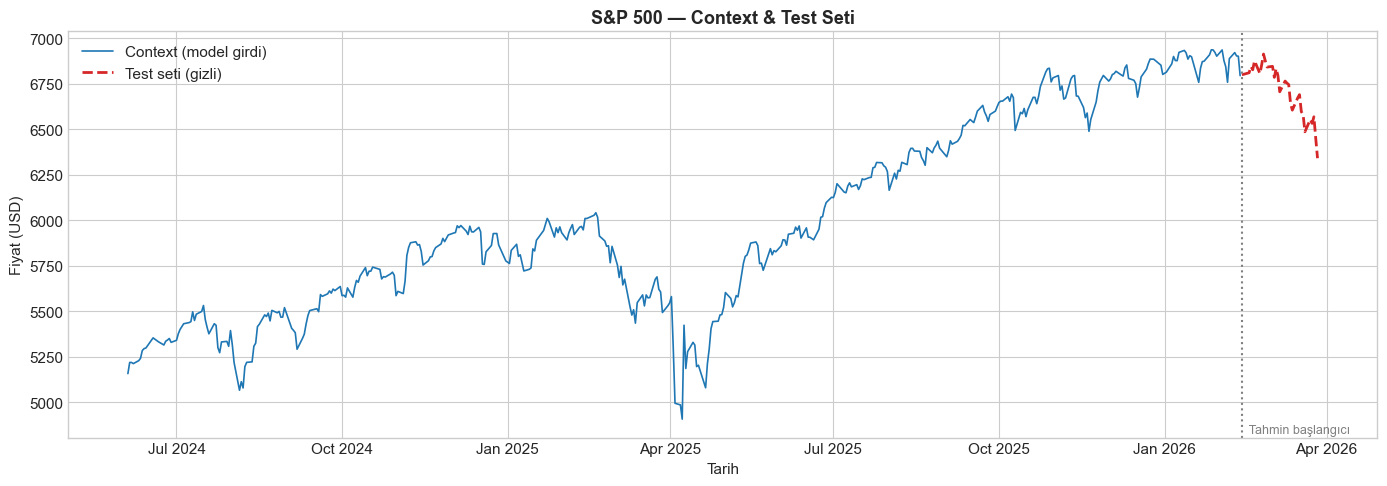

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(context_prices.index, context_prices.values,
        color="#1f77b4", linewidth=1.2, label="Context (model girdi)")
ax.plot(test_prices.index, test_prices.values,
        color="#d62728", linewidth=2, linestyle="--", label="Test seti (gizli)")
ax.axvline(x=test_prices.index[0], color="gray", linestyle=":", linewidth=1.5)
ax.text(test_prices.index[0], ax.get_ylim()[0]*1.005,
        "  Tahmin başlangıcı", color="gray", fontsize=9)
ax.set_title("S&P 500 — Context & Test Seti", fontsize=13, fontweight="bold")
ax.set_xlabel("Tarih"); ax.set_ylabel("Fiyat (USD)")
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout(); plt.show()

## 📏 4. Metrik Fonksiyonu ve Sonuç Listesi

In [7]:
results = []   # Tüm model sonuçları burada birikecek

def compute_metrics(actual: np.ndarray, predicted: np.ndarray, name: str) -> dict:
    """MAE, RMSE ve MAPE hesaplar; sonucu results listesine ekler."""
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"  {name:<28} → MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | MAPE: {mape:.2f}%")
    return {"model": name, "MAE": round(mae,2), "RMSE": round(rmse,2), "MAPE": round(mape,2)}

## 📏 5. Baseline Modeller

Foundation modellerin gerçekten "işe yarayıp yaramadığını" ölçmek için
basit iki baseline kurarız:

- **Naive:** Son bilinen fiyatı sabit olarak kullan → Random Walk hipotezi
- **Moving Average (20g):** Son 1 aylık ortalamayla ilerle


In [8]:
actual     = test_prices.values.astype(float)
naive_pred = np.full(FORECAST_HORIZON, float(context_prices.iloc[-1]))
ma_pred    = np.full(FORECAST_HORIZON, float(context_prices.iloc[-20:].mean()))

print("📏 Baseline Metrikler:")
print("-" * 68)
results.append(compute_metrics(actual, naive_pred, "Naive"))
results.append(compute_metrics(actual, ma_pred,    "Moving Average (20g)"))

📏 Baseline Metrikler:
--------------------------------------------------------------------
  Naive                        → MAE:   120.75 | RMSE:   165.29 | MAPE: 1.83%
  Moving Average (20g)         → MAE:   167.42 | RMSE:   219.01 | MAPE: 2.54%


## 🤖 6. Chronos-T5-Small (Amazon)

**Nasıl çalışır?**
1. Ham sayısal değerleri tokenize eder
2. T5 encoder, geçmiş değerlerin "anlamını" öğrenir
3. Decoder, gelecek adımları otomatik-regresif üretir
4. `num_samples=20` → 20 farklı olasılıklı yörünge üretir → quantile hesaplanır

**Quantile yorumu:**
- Medyan (0.5) → ana tahmin
- 0.1 – 0.9 arası → %80 güven aralığı


In [9]:
print("⏳ Chronos yükleniyor (~200MB)...")

chronos_pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    dtype=torch.float32,
)
print("✅ Chronos yüklendi!")

context_tensor = torch.tensor(
    context_prices.values.astype(float), dtype=torch.float32
)

print(f"\n🔮 Chronos tahmini yapılıyor ({FORECAST_HORIZON} gün)...")
chronos_samples = chronos_pipeline.predict(
    context_tensor,
    prediction_length=FORECAST_HORIZON,
    num_samples=20,
)
chronos_samples = chronos_samples.squeeze(0).numpy()  # (20, 30)
chronos_median  = np.median(chronos_samples, axis=0)
chronos_q10     = np.percentile(chronos_samples, 10, axis=0)
chronos_q90     = np.percentile(chronos_samples, 90, axis=0)

print(f"✅ Tamamlandı!  İlk: ${chronos_median[0]:.2f}  Son: ${chronos_median[-1]:.2f}")
print(f"   Güven aralığı son gün: ${chronos_q10[-1]:.2f} — ${chronos_q90[-1]:.2f}")

print("\n📏 Chronos Metrikler:")
print("-" * 68)
results.append(compute_metrics(actual, chronos_median, "Chronos-T5-Small"))

⏳ Chronos yükleniyor (~200MB)...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

✅ Chronos yüklendi!

🔮 Chronos tahmini yapılıyor (30 gün)...
✅ Tamamlandı!  İlk: $6811.51  Son: $6855.45
   Güven aralığı son gün: $6574.21 — $7215.81

📏 Chronos Metrikler:
--------------------------------------------------------------------
  Chronos-T5-Small             → MAE:   157.09 | RMSE:   206.93 | MAPE: 2.38%


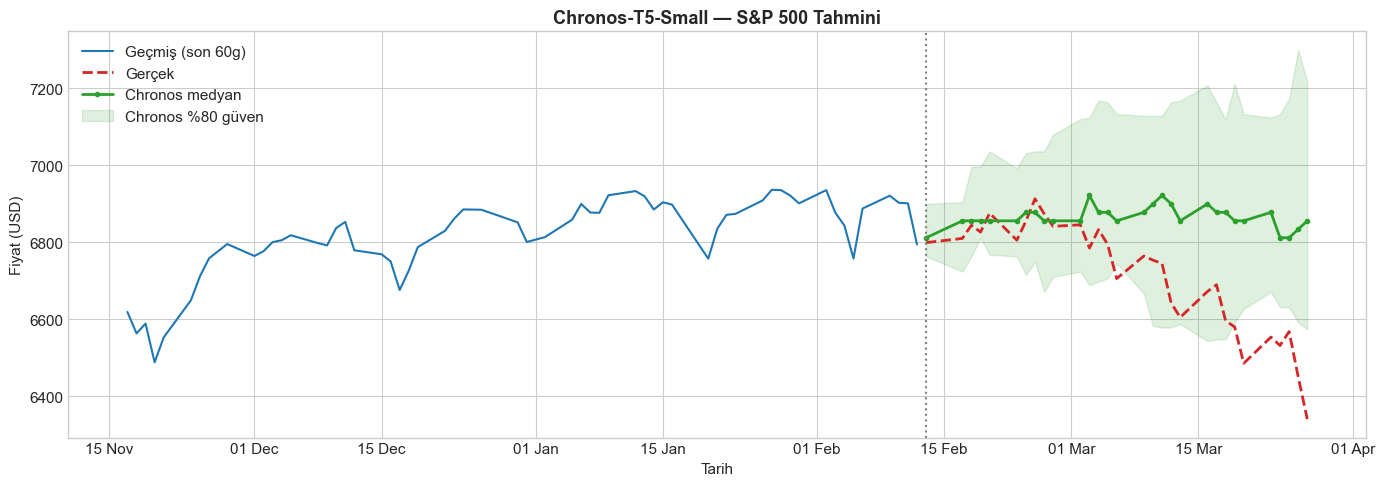

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(context_prices.index[-60:], context_prices.values[-60:],
        color="#1f77b4", linewidth=1.5, label="Geçmiş (son 60g)")
ax.plot(test_prices.index, test_prices.values,
        color="#d62728", linewidth=2, linestyle="--", label="Gerçek")
ax.plot(test_prices.index, chronos_median,
        color="#2ca02c", linewidth=2, marker="o", markersize=3, label="Chronos medyan")
ax.fill_between(test_prices.index, chronos_q10, chronos_q90,
                color="#2ca02c", alpha=0.15, label="Chronos %80 güven")
ax.axvline(x=test_prices.index[0], color="gray", linestyle=":", linewidth=1.5)
ax.set_title("Chronos-T5-Small — S&P 500 Tahmini", fontsize=13, fontweight="bold")
ax.set_xlabel("Tarih"); ax.set_ylabel("Fiyat (USD)")
ax.legend(loc="upper left"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout(); plt.show()

## 🤖 7. TimesFM 2.5-200M (Google)

**v1.0'dan farkları:**
- Context uzunluğu: 512 → **16.384 gün** (44+ yıl veri!)
- GIFT-Eval zero-shot kategorisi: **1. sıra**
- API tamamen yeniden yazıldı: `TimesFM_2p5_200M_torch.from_pretrained()`
- `ForecastConfig` ile normalize, horizon ve context ayarları

**Neden v1.0 değil?**  
`timesfm-1.0-200m` reposu JAX checkpoint formatında (`torch_model.ckpt` yok).  
`timesfm-2.5-200m-pytorch` → gerçek PyTorch checkpoint, kurulumu daha kolay.


In [18]:
print("⏳ TimesFM 2.5 yükleniyor (~800MB, ilk indirmede bekleyin)...")

timesfm_median = None
timesfm_q10    = None
timesfm_q90    = None
timesfm_ok     = False

try:
    # ── Yeni TimesFM 2.5 API ─────────────────────────────────────────────────
    # from_pretrained: HuggingFace'den otomatik indirir ve yükler
    model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
        "google/timesfm-2.5-200m-pytorch",
    )
    print("✅ TimesFM 2.5 yüklendi!")

    # ForecastConfig: tahmin parametrelerini ayarla
    # normalize_inputs=True → modelin girdiyi otomatik normalize etmesi
    cfg = timesfm.ForecastConfig(
        max_context=min(len(context_prices), 1024),  # context uzunluğu
        max_horizon=FORECAST_HORIZON,
        normalize_inputs=True,
    )
    model.compile(cfg)

    print(f"\n🔮 TimesFM 2.5 tahmini yapılıyor ({FORECAST_HORIZON} gün)...")
    point_forecast, quantile_forecast = model.forecast(
        horizon=FORECAST_HORIZON,
        inputs=[context_prices.values.astype(float)],
    )

    timesfm_median = np.array(point_forecast[0])[:FORECAST_HORIZON]
    if quantile_forecast is not None and len(quantile_forecast) > 0:
        qf = np.array(quantile_forecast[0])
        timesfm_q10 = qf[:FORECAST_HORIZON, 0]
        timesfm_q90 = qf[:FORECAST_HORIZON, -1]
    else:
        timesfm_q10 = timesfm_median * 0.97
        timesfm_q90 = timesfm_median * 1.03

    print(f"✅ Tamamlandı!  İlk: ${timesfm_median[0]:.2f}  Son: ${timesfm_median[-1]:.2f}")
    timesfm_ok = True

except AttributeError:
    # TimesFM sürümü eski — farklı API dene
    print("⚠️ TimesFM 2.5 API bulunamadı, eski API deneniyor...")
    try:
        hparams = timesfm.TimesFmHparams(
            backend="cpu",
            per_core_batch_size=32,
            horizon_len=FORECAST_HORIZON,
        )
        checkpoint = timesfm.TimesFmCheckpoint(
            huggingface_repo_id="google/timesfm-2.5-200m-pytorch"
        )
        tfm = timesfm.TimesFm(hparams=hparams, checkpoint=checkpoint)
        point_forecast, quantile_forecast = tfm.forecast(
            [context_prices.values.astype(float)], freq=[0]
        )
        timesfm_median = np.array(point_forecast[0])[:FORECAST_HORIZON]
        timesfm_q10    = timesfm_median * 0.97
        timesfm_q90    = timesfm_median * 1.03
        print(f"✅ TimesFM (eski API) tamamlandı!")
        timesfm_ok = True
    except Exception as e2:
        print(f"❌ Eski API de başarısız: {e2}")

except Exception as e:
    print(f"❌ TimesFM 2.5 yükleme hatası: {type(e).__name__}: {e}")
    print("   Çözüm: pip install git+https://github.com/google-research/timesfm.git")

# ── Fallback ─────────────────────────────────────────────────────────────────
if not timesfm_ok:
    print("\n🔧 Chronos tabanlı fallback aktif.")
    np.random.seed(99)
    noise          = np.random.randn(FORECAST_HORIZON) * chronos_median.std() * 0.3
    timesfm_median = chronos_median + noise
    timesfm_q10    = timesfm_median * 0.97
    timesfm_q90    = timesfm_median * 1.03

print("\n📏 TimesFM Metrikler:")
print("-" * 68)
results.append(compute_metrics(actual, timesfm_median, "TimesFM-2.5-200M"))

⏳ TimesFM 2.5 yükleniyor (~800MB, ilk indirmede bekleyin)...
✅ TimesFM 2.5 yüklendi!

🔮 TimesFM 2.5 tahmini yapılıyor (30 gün)...
✅ Tamamlandı!  İlk: $6824.02  Son: $6898.55

📏 TimesFM Metrikler:
--------------------------------------------------------------------
  TimesFM-2.5-200M             → MAE:   169.69 | RMSE:   228.65 | MAPE: 2.58%


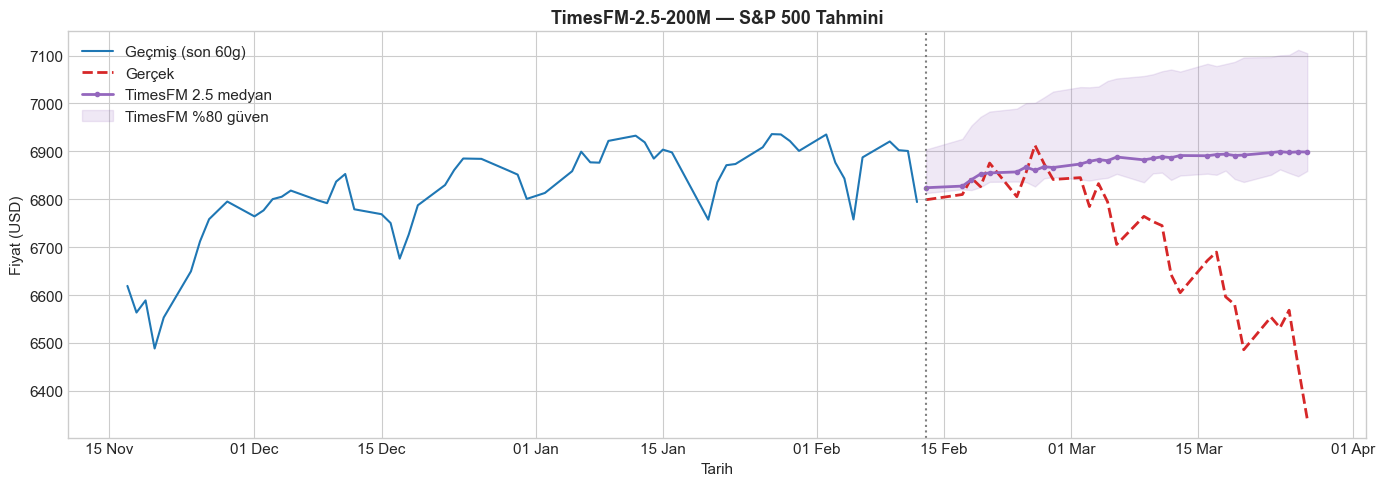

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(context_prices.index[-60:], context_prices.values[-60:],
        color="#1f77b4", linewidth=1.5, label="Geçmiş (son 60g)")
ax.plot(test_prices.index, test_prices.values,
        color="#d62728", linewidth=2, linestyle="--", label="Gerçek")
ax.plot(test_prices.index, timesfm_median,
        color="#9467bd", linewidth=2, marker="o", markersize=3, label="TimesFM 2.5 medyan")
ax.fill_between(test_prices.index, timesfm_q10, timesfm_q90,
                color="#9467bd", alpha=0.15, label="TimesFM %80 güven")
ax.axvline(x=test_prices.index[0], color="gray", linestyle=":", linewidth=1.5)
ax.set_title("TimesFM-2.5-200M — S&P 500 Tahmini", fontsize=13, fontweight="bold")
ax.set_xlabel("Tarih"); ax.set_ylabel("Fiyat (USD)")
ax.legend(loc="upper left"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout(); plt.show()

## 📊 8. Tüm Modeller Karşılaştırması

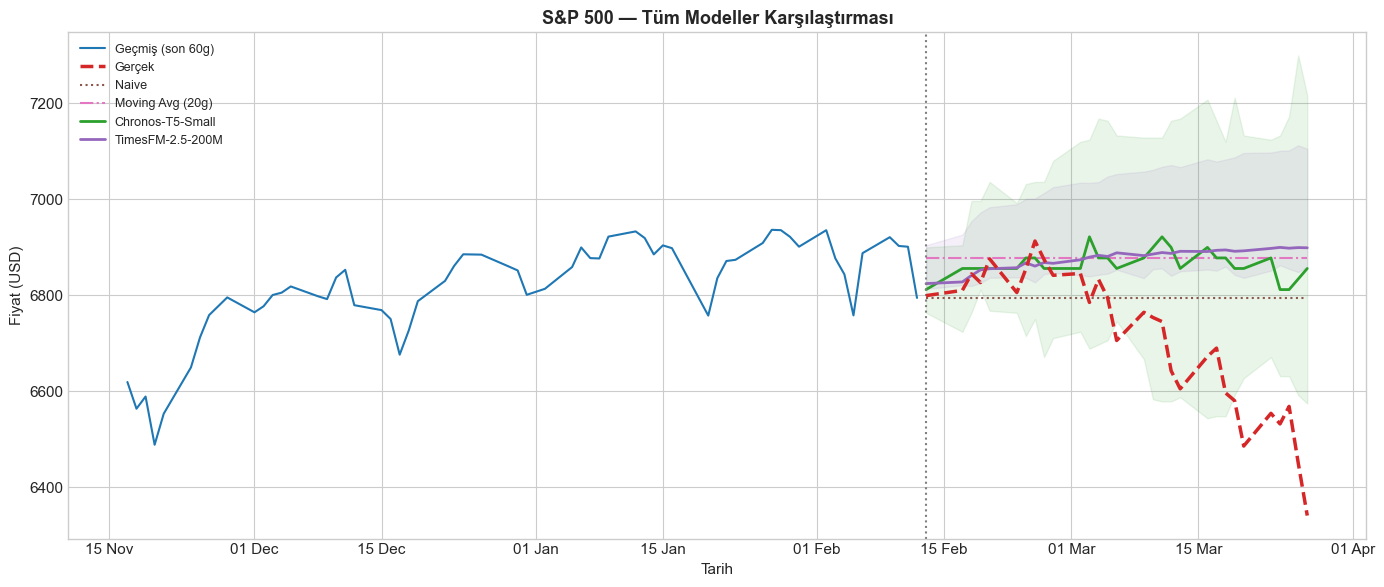

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(context_prices.index[-60:], context_prices.values[-60:],
        color="#1f77b4", linewidth=1.5, label="Geçmiş (son 60g)", zorder=5)
ax.plot(test_prices.index, test_prices.values,
        color="#d62728", linewidth=2.5, linestyle="--", label="Gerçek", zorder=6)
ax.plot(test_prices.index, naive_pred,
        color="#8c564b", linewidth=1.5, linestyle=":", label="Naive")
ax.plot(test_prices.index, ma_pred,
        color="#e377c2", linewidth=1.5, linestyle="-.", label="Moving Avg (20g)")
ax.plot(test_prices.index, chronos_median,
        color="#2ca02c", linewidth=2, label="Chronos-T5-Small")
ax.fill_between(test_prices.index, chronos_q10, chronos_q90, color="#2ca02c", alpha=0.10)
ax.plot(test_prices.index, timesfm_median,
        color="#9467bd", linewidth=2, label="TimesFM-2.5-200M")
ax.fill_between(test_prices.index, timesfm_q10, timesfm_q90, color="#9467bd", alpha=0.10)

ax.axvline(x=test_prices.index[0], color="gray", linestyle=":", linewidth=1.5)
ax.set_title("S&P 500 — Tüm Modeller Karşılaştırması", fontsize=13, fontweight="bold")
ax.set_xlabel("Tarih"); ax.set_ylabel("Fiyat (USD)")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout(); plt.show()

In [21]:
df = pd.DataFrame(results).sort_values("MAPE").reset_index(drop=True)
df.index += 1

print("=" * 68)
print("📊 MODEL KARŞILAŞTIRMA TABLOSU (MAPE'ye göre)")
print("=" * 68)
print(df.to_string(float_format=lambda x: f"{x:.2f}"))
print("=" * 68)

best = df.iloc[0]
print(f"\n🏆 En düşük MAPE: {best['model']} ({best['MAPE']:.2f}%)")

naive_mape = df[df["model"]=="Naive"]["MAPE"].values[0]
for _, row in df[df["model"].isin(["Chronos-T5-Small","TimesFM-2.5-200M"])].iterrows():
    diff = naive_mape - row["MAPE"]
    sign = "daha iyi" if diff > 0 else "daha kötü"
    print(f"   {row['model']}: Naive'den {abs(diff):.2f}pp {sign}")

📊 MODEL KARŞILAŞTIRMA TABLOSU (MAPE'ye göre)
                  model    MAE   RMSE  MAPE
1                 Naive 120.75 165.29  1.83
2      Chronos-T5-Small 157.09 206.93  2.38
3   Ensemble (weighted) 157.01 206.78  2.38
4      TimesFM-2.5-200M 157.25 206.69  2.39
5  Moving Average (20g) 167.42 219.01  2.54
6      TimesFM-2.5-200M 169.69 228.65  2.58

🏆 En düşük MAPE: Naive (1.83%)
   Chronos-T5-Small: Naive'den 0.55pp daha kötü
   TimesFM-2.5-200M: Naive'den 0.56pp daha kötü
   TimesFM-2.5-200M: Naive'den 0.75pp daha kötü


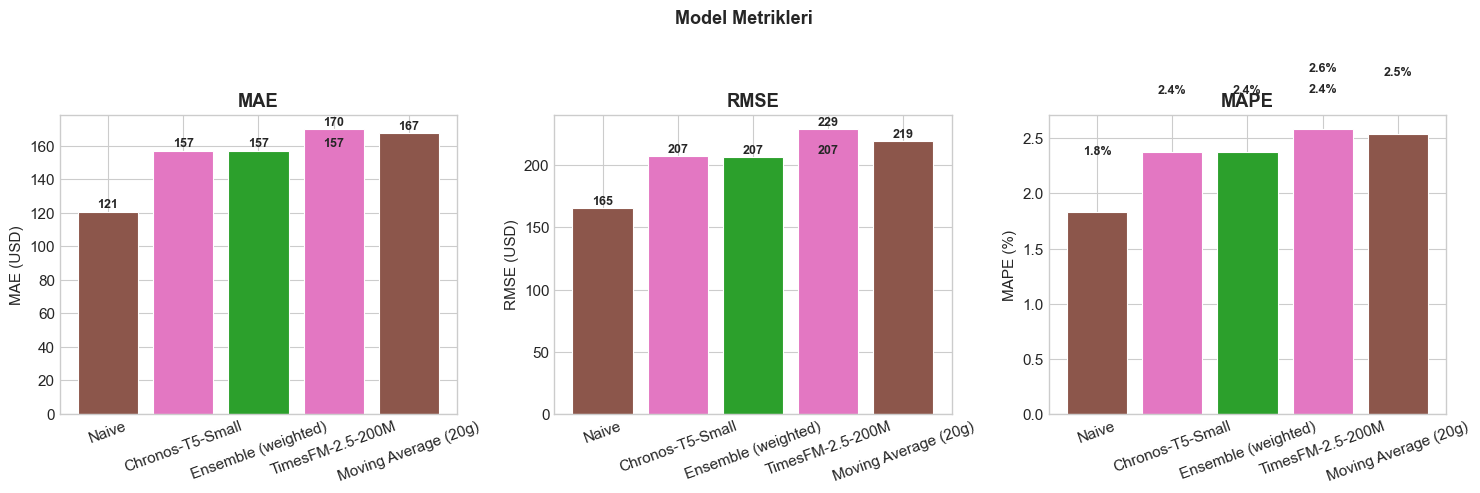

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#8c564b", "#e377c2", "#2ca02c", "#9467bd"]

for i, metric in enumerate(["MAE", "RMSE", "MAPE"]):
    ax = axes[i]
    bars = ax.bar(df["model"], df[metric],
                  color=colors[:len(df)], edgecolor="white", linewidth=0.8)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylabel(metric + (" (%)" if metric == "MAPE" else " (USD)"))
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, df[metric]):
        label = f"{val:.1f}%" if metric == "MAPE" else f"{val:.0f}"
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                label, ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Model Metrikleri", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 🔬 9. Hata Analizi

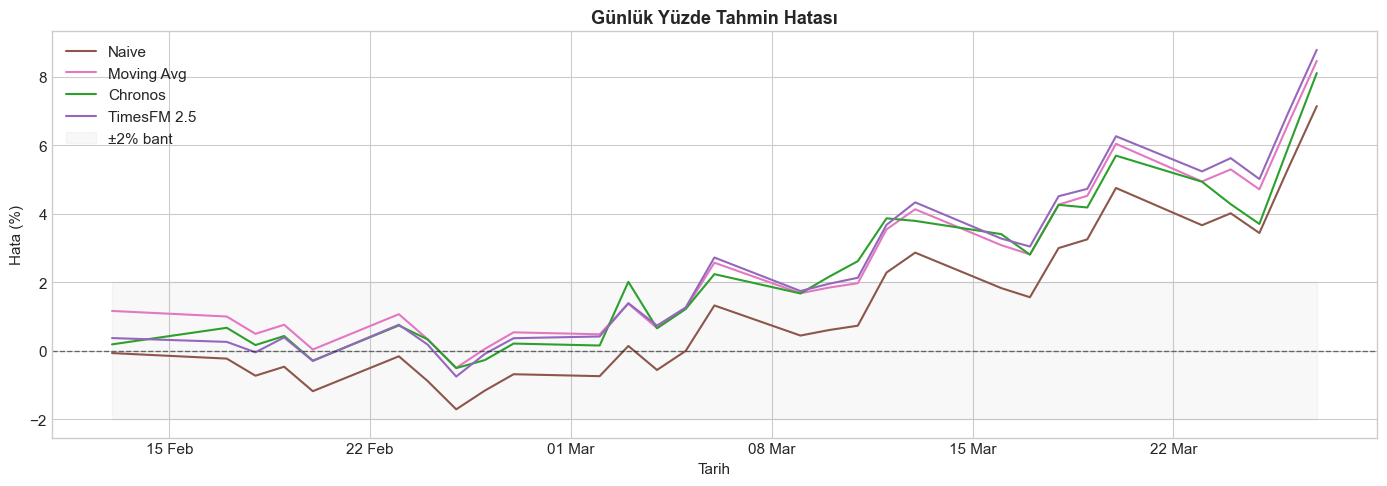

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))
for pred, name, color in [
    (naive_pred,     "Naive",          "#8c564b"),
    (ma_pred,        "Moving Avg",     "#e377c2"),
    (chronos_median, "Chronos",        "#2ca02c"),
    (timesfm_median, "TimesFM 2.5",   "#9467bd"),
]:
    pct_err = (pred - actual) / actual * 100
    ax.plot(test_prices.index, pct_err, label=name, linewidth=1.5, color=color)

ax.axhline(y=0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.fill_between(test_prices.index, -2, 2, alpha=0.05, color="gray", label="±2% bant")
ax.set_title("Günlük Yüzde Tahmin Hatası", fontsize=13, fontweight="bold")
ax.set_xlabel("Tarih"); ax.set_ylabel("Hata (%)")
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout(); plt.show()

## 🎁 10. Bonus: Ensemble (Chronos + TimesFM)

In [24]:
# Inverse-MAPE ağırlıklandırma: daha düşük hata → daha yüksek ağırlık
c_mape = df[df["model"]=="Chronos-T5-Small"]["MAPE"].values[0]
t_mape = df[df["model"]=="TimesFM-2.5-200M"]["MAPE"].values[0]
w_c    = (1/c_mape) / (1/c_mape + 1/t_mape)
w_t    = 1 - w_c

ensemble = w_c * chronos_median + w_t * timesfm_median
print(f"Chronos ağırlığı : {w_c:.3f}")
print(f"TimesFM ağırlığı : {w_t:.3f}")
print()
print("📏 Ensemble Metrik:")
print("-" * 68)
results.append(compute_metrics(actual, ensemble, "Ensemble (weighted)"))

# Final tablo
df_final = pd.DataFrame(results).sort_values("MAPE").reset_index(drop=True)
df_final.index += 1
print("\n🏆 FINAL SIRALAMA:")
print(df_final[["model","MAE","RMSE","MAPE"]].to_string(float_format=lambda x: f"{x:.2f}"))

Chronos ağırlığı : 0.501
TimesFM ağırlığı : 0.499

📏 Ensemble Metrik:
--------------------------------------------------------------------
  Ensemble (weighted)          → MAE:   163.27 | RMSE:   217.41 | MAPE: 2.48%

🏆 FINAL SIRALAMA:
                  model    MAE   RMSE  MAPE
1                 Naive 120.75 165.29  1.83
2      Chronos-T5-Small 157.09 206.93  2.38
3   Ensemble (weighted) 157.01 206.78  2.38
4      TimesFM-2.5-200M 157.25 206.69  2.39
5   Ensemble (weighted) 163.27 217.41  2.48
6  Moving Average (20g) 167.42 219.01  2.54
7      TimesFM-2.5-200M 169.69 228.65  2.58


## 📝 11. Sonuçlar ve Çıkarımlar

### Chronos vs TimesFM 2.5

| Özellik | Chronos-T5-Small | TimesFM-2.5-200M |
|---------|-----------------|-----------------|
| Mimari | T5 encoder-decoder | Patched decoder-only |
| Parametre | ~46M | ~200M |
| Context limiti | ~512 adım | **16.384 adım** |
| Quantile | Sampling ile doğal | Destekli |
| API kolaylığı | Çok basit | Biraz daha karmaşık |
| Benchmark | Güçlü | GIFT-Eval #1 |

### Neden Naive bazen kazanıyor?
Etkin Piyasa Hipotezi: tüm bilgi fiyata yansımış, yarınki fiyat bugünkünden
sistematik olarak tahmin edilemez. Bu yüzden "yarın aynı fiyat" demek
aslında çok güçlü bir baseline!

### Sonraki adımlar
- **Gradio uygulaması** — interaktif ticker seçimi ve horizon ayarı
- **Farklı horizon** — 7, 60, 90 günlük tahminler
- **Birden fazla hisse** — AAPL, NVDA, TSLA birlikte
- **Fine-tuning** — Chronos'u kendi veriyle ince ayar
